<div align='center'>
    <h1>Jurnal Praktikum Dasar Kecerdasan Artifisial</h1>
    <h3>Modul 7: Implementasi Uniform Cost Search</h3>
</div>

### Tujuan Praktikum
- Mahasiswa memahami dan mampu mengimplementasikan algoritma *Uniform Cost Search* pada Python dengan menggunakan *library* NetworkX.

## Petunjuk Umum
1. **Jangan lupa untuk selalu import *library* NetworkX & Matplotlib ketika memulai sesi baru (run time) atau kode Python yang memerlukan penggunaan library NetworkX**
2. **Jangan ubah struktur kode yang diberikan, cukup isi bagian yang kosong.**
3. **Jalankan setiap sel satu per satu agar tidak ada error.**
4. **Kerjakan soal yang ada secara berurutan, dikarenakan soal akan meneruskan code soal sebelumnya**

In [1]:
print("'Aarif Rahmaan Jalaluddin Faqiih")  # Tuliskan nama lengkap Anda
print("103112430182")  # Tuliskan NIM Anda
print("IF-12-06")  # Tuliskan kelas Anda
print("https://colab.research.google.com/drive/1eACcdZTvVMm-3P8-9sqE-jLEmj5knx1B?usp=sharing") # Link collab Praktikum
print("https://colab.research.google.com/drive/1Dq-RicXzo8QAYYnCFdVQgPZIXSjqeGwz?usp=sharing") # Link collab Jurnal
print("https://github.com/aariffaqiih/CAK2HAB3-DASAR-KECERDASAN-ARTIFISIAL/tree/main/MODUL%2007%20IMPLEMENTASI%20UNIFORM%20COST%20SEARCH")

'Aarif Rahmaan Jalaluddin Faqiih
103112430182
IF-12-06
https://colab.research.google.com/drive/1eACcdZTvVMm-3P8-9sqE-jLEmj5knx1B?usp=sharing
https://colab.research.google.com/drive/1Dq-RicXzo8QAYYnCFdVQgPZIXSjqeGwz?usp=sharing
https://github.com/aariffaqiih/CAK2HAB3-DASAR-KECERDASAN-ARTIFISIAL/tree/main/MODUL%2007%20IMPLEMENTASI%20UNIFORM%20COST%20SEARCH


In [2]:
import networkx as nx # Library untuk membuat graf
import matplotlib.pyplot as plt # Library bantuan untuk mencetak visualisasi graf


### Fungsi pendukung untuk mencetak graf

#### **!! Tidak usah dimodifikasi !!**

In [3]:
pos = {
    'A': (0, 0),   # Posisi node A
    'B': (1, 3),   # Posisi node B
    'C': (2, 0),   # Posisi node C
    'D': (4, 2),   # Posisi node D
    'E': (6, 0),   # Posisi node E
    'F': (5, -2)   # Posisi node F
}

In [4]:
# Fungsi pendukung untuk mencetak graf
def show_graph(G, pos=None, title='') :
  # Membuat pos jika pos tidak diberikan
  if pos is None:
      pos = nx.spring_layout(G)

  # Fungsi untuk menggambar node
  nx.draw(
      G,                  # Graf NetworkX
      pos,                # Posisi node
      with_labels=True,   # Menampilkan nama node
      node_color='red',   # Warna node
      node_size=2000,     # Ukuran node
      font_color="white", # Warna font label node
      font_weight="bold", # Ketebalan font label node
      width=5             # Ketebalan garis edge
  )

  # Mengambil label edge jika ada weight
  edge_labels = nx.get_edge_attributes(G, 'weight')
  # Fungsi untuk menggambar node
  nx.draw_networkx_edge_labels(
      G,
      pos,
      edge_labels=edge_labels, # Data weight
      font_color='blue',       # Warna font label edge
      font_weight="bold",      # Berat font label edge
      font_size=16,            # Ukuran font label edge
  )

  plt.margins(0.2)  # Memberikan margin pada plot
  plt.title(title)  # Menampilkan judul graf jika diberikan
  plt.show()

### 1. Implementasi UCS pada `Weighted Undirected Graph` (30)

Seorang kurir barang bekerja di sebuah kota besar. Tugasnya adalah mengirimkan barang dari satu titik ke titik lainnya dengan jarak tempuh yang seminimal  mungkin. Kota tersebut memiliki beberapa titik yang dihubungkan oleh berbagai jalan. Setiap jalan memiliki bobot yang merepresentasikan jarak antar titik.

Bantulah kurir tersebut menemukan rute terpendek antara 2 tempat berdasarkan input yang diberikan.

**a. (5 poin)** Inisialisasi graf bernama `kota` menggunakan **graf tidak berarah**.

In [5]:
# Inisialisasi graf tidak berarah
kota = nx.Graph()


**b. (5 poin)** Tambahkan node untuk merepresentasikan setiap lokasi di kota tersebut. Nama node adalah sebagai berikut :
- Node `A`
- Node `B`
- Node `C`
- Node `D`
- Node `E`
- Node `F`

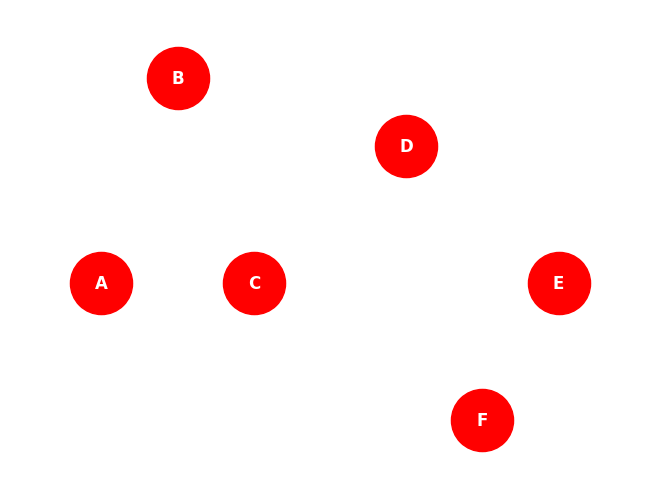

In [6]:
# List daftar nama titik di dalam kota
nodes = ['A', 'B', 'C', 'D', 'E', 'F']

# Tambahkan node dari list variabel `nodes` pada graf kota
kota.add_nodes_from(nodes)

# Tampilkan graf kota setelah penambahan node
show_graph(kota, pos)


Contoh *output*:

![Contoh output penambahan lokasi](./asset/1_addnodekota.png)

**c. (5 poin)** Pada graf kota, setiap edge mewakili hubungan antara dua lokasi, dan masing-masing hubungan memiliki jarak tempuh tertentu yang direpresentasikan sebagai `weight` pada graf. Berikut ini adalah jarak lokasi antara titik yang ada di kota tersebut:

- `A` ke `B`: 4 km.
- `A` ke `C`: 2 km.
- `B` ke `C`: 5 km.
- `B` ke `D`: 10 km.
- `C` ke `D`: 3 km.
- `C` ke `E`: 8 km.
- `D` ke `E`: 2 km.
- `D` ke `F`: 6 km.
- `E` ke `F`: 3 km.

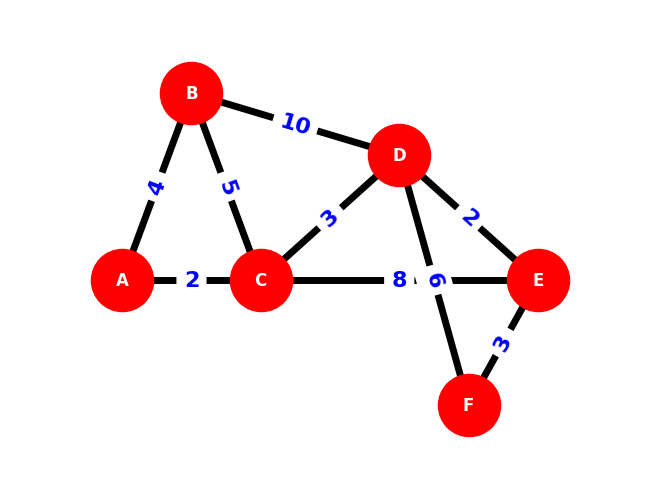

In [7]:
# Daftar jarak antara dua titik pada kota
edges = [
    ('A', 'B', 4),
    ('A', 'C', 2),
    ('B', 'C', 5),
    ('B', 'D', 10),
    ('C', 'D', 3),
    ('C', 'E', 8),
    ('D', 'E', 2),
    ('D', 'F', 6),
    ('E', 'F', 3),
]

# Tambahkan jarak yang menghubungkan antara dua titik ke dalam graf kota
kota.add_weighted_edges_from(edges)

# Tampilkan graf kota setelah penambahan edge
show_graph(kota, pos)


Contoh *output*:

![Contoh output penambahan lokasi](./asset/2_addedgekota.png)

**d. (5 poin)** Pada potongan kode dibawah, buat fungsi `heuristable(a, b)`. Karena UCS tidak memperhatikan nilai heuristik, maka cukup kembalikan 0.

In [8]:
def heuristable(a, b):
    return 0


**e. (10 poin)** Pada potongan kode dibawah, buat kode untuk menemukan rute terpendek dengan mempertimbangkan jarak total antara lokasi awal dan lokasi tujuan yang dimasukkan oleh pengguna.

Dalam proses pencarian rute, gunakan algoritma *Uniform Cost Search (UCS)* yang diimplementasikan menggunakan `astar_path()` pada NetworkX dengan nilai heuristik 0 yang sudah didefinisikan pada fungsi `heuristable()`.

Kemudian tampilkan rute terpendek yang sudah dicari antara titik awal dan titik tujuan yang sudah dimasukkan oleh user serta tampilkan juga besar jarak yang ditempuh dari titik awal ke titik tujuan tersebut.

In [9]:
# Minta input dari pengguna untuk titik awal dan titik tujuan
start_node = input('Masukkan titik awal: ')
end_node = input('Masukkan titik tujuan: ')

# Mencari titik yang dikunjungi dari titik awal ke titik tujuan
path = nx.astar_path(
    kota,
    start_node,
    end_node,
    heuristic=heuristable,
    weight='weight'
)

# Menghitung jarak dari titik awal ke titik tujuan
path_length = nx.astar_path_length(
    kota, start_node, end_node, heuristic=heuristable, weight='weight'
)

# Cetak hasil
print(f'Titik yang dikunjungi dari {start_node} ke {end_node}: {path}')
print(f'Besar weight terkecil dari {start_node} ke {end_node}: {path_length} km')


Masukkan titik awal: B
Masukkan titik tujuan: F
Titik yang dikunjungi dari B ke F: ['B', 'C', 'D', 'E', 'F']
Besar weight terkecil dari B ke F: 13 km


# Penjelasan

Program ini berfungsi untuk menampilkan graf kota beserta jarak antar titik, lalu mencari rute terpendek dari titik awal ke titik tujuan menggunakan algoritma A* dengan bantuan library NetworkX.

Pertama, dibuat dictionary bernama `pos` yang berisi koordinat (x, y) untuk setiap node yaitu A, B, C, D, E, dan F. Posisi ini nantinya dipakai untuk mengatur letak node saat digambar.

Kemudian dibuat fungsi pendukung bernama `show_graph` yang bertugas untuk mencetak graf lengkap dengan node, edge, dan label bobotnya.

Di dalam fungsi `show_graph`, pertama dicek apakah parameter `pos` bernilai `None`. Jika iya, maka posisi node akan dibuat otomatis oleh `nx.spring_layout`.

Setelah itu, fungsi `nx.draw` digunakan untuk menggambar node-node graf. Disini ada beberapa parameter yang diatur, mulai dari `G` yaitu graf yang mau digambar, `pos` untuk posisi node, `with_labels=True` biar nama node muncul, `node_color='red'` artinya warna node merah, `node_size=2000` ukuran node, `font_color="white"` warna tulisan di node putih, `font_weight="bold"` biar tebal, dan `width=5` ketebalan garis edge.

Selanjutnya, `edge_labels = nx.get_edge_attributes(G, 'weight')` berfungsi untuk mengambil semua bobot (jarak) dari setiap edge. Lalu `nx.draw_networkx_edge_labels` dipanggil untuk menggambar label bobot tersebut di tengah-tengah edge, dengan warna biru, tebal, dan ukuran font 16.

Setelah itu, `plt.margins(0.2)` memberikan sedikit ruang kosong di sekeliling plot supaya tidak terpotong, dan `plt.title(title)` menampilkan judul jika ada. Terakhir `plt.show()` untuk menampilkan gambar graf di layar.

Setelah fungsi `show_graph` siap, program membuat graf tidak berarah dengan `nx.Graph()` dan disimpan di variabel `kota`. Kemudian dibuat list `nodes` berisi nama titik dari 'A' sampai 'F'. Dengan `kota.add_nodes_from(nodes)`, semua node tersebut dimasukkan ke dalam graf. Dari sini, graf `kota` sudah punya node tapi belum punya edge.
F
Maka dipanggil `show_graph(kota, pos)` untuk menampilkan graf yang masih kosong tanpa garis penghubung. Kemudian program mendefinisikan `edges` yaitu list yang berisi tuple tiga nilai: titik awal, titik akhir, dan jarak (bobot). Misalnya ('A', 'B', 4) artinya jarak dari A ke B adalah 4 km, dan seterusnya. Setelah itu, `kota.add_weighted_edges_from(edges)` menambahkan semua edge berbobot tersebut ke graf kota. Untuk melihat perubahan setelah ada edge, `show_graph(kota, pos)` dipanggil lagi.

Selanjutnya dibuat fungsi `heuristable(a, b)` yang selalu mengembalikan nilai 0. Fungsi ini sebenarnya untuk estimasi jarak dari node `a` ke node `b` dalam algoritma A*, tapi karena isinya 0 maka algoritma A* akan berperilaku sama seperti Dijkstra (mencari jarak sebenarnya tanpa bantuan heuristik).

Setelah itu program meminta input dari pengguna untuk titik awal (`start_node`) dan titik tujuan (`end_node`) menggunakan fungsi `input`. Kedua input ini disimpan sebagai string. Lalu `nx.astar_path` digunakan untuk mencari urutan node yang dikunjungi dari `start_node` ke `end_node`.

Parameter yang diberikan adalah graf `kota`, titik awal, titik tujuan, fungsi heuristik (`heuristable`), dan bobot yang dipakai yaitu `'weight'`. Hasilnya disimpan di variabel `path`. Kemudian `nx.astar_path_length` dipanggil dengan parameter serupa untuk menghitung total jarak dari titik awal ke titik tujuan, hasilnya disimpan di `path_length`.

Terakhir, program mencetak dua baris: pertama menampilkan titik-titik yang dilalui (misal dari A ke C lewat mana saja), dan kedua menampilkan besar weight terkecil dalam satuan kilometer.

Contoh *output*:

|input|output|
|-----|------|
|Masukkan titik awal: `B`<br>Masukkan titik tujuan: `F`|Titik yang dikunjungi dari B ke F: ['B', 'C', 'D', 'E', 'F']<br>Besar weight terkecil dari B ke F: 13 km|
|Masukkan titik awal: `A`<br>Masukkan titik tujuan: `D`|Titik yang dikunjungi dari A ke D: ['A', 'C', 'D']<br>Besar weight terkecil dari A ke D: 5 km|

### 2. Implementasi UCS pada `Weighted Directed Graph` (30)

Seorang detektif sedang menyelidiki jaringan kejahatan di sebuah kota besar. Detektif tersebut menemukan peta yang berisi rute rahasia yang menghubungkan beberapa lokasi markas jaringan kriminal yang menyembunyikan tempat penyimpanan barang ilegal. Namun, rute rahasia ini hanya bisa dilewati satu arah saja.

Bantu detektif mencari rute terpendek dari suatu lokasi ke lokasi lainnya dengan membuat graf pada NetworkX dan implementasikan algoritma *Uniform Cost Search (UCS)* untuk mencari rute yang dilalui dan menghitung jarak antara dua titik tersebut.

### Fungsi pendukung untuk mencetak graf

#### **!! Tidak usah dimodifikasi !!**

In [10]:
pos = {
    'NullPointer': (0, 0),
    'RootAccess': (1, 5),
    'DataBreach': (2, 0),
    'SyntaxError': (4, 4),
    'BinaryBlasters': (6, 0),
    'CyberPatrol': (5, -3)
}

In [11]:
# Fungsi pendukung untuk mencetak graf
def show_graph(G, pos=None, title='') :
  # Membuat pos jika pos tidak diberikan
  if pos is None:
      pos = nx.spring_layout(G)

  # Fungsi untuk menggambar node
  nx.draw(
      G,                  # Graf NetworkX
      pos,                # Posisi node
      with_labels=True,   # Menampilkan nama node
      node_color='red',   # Warna node
      node_size=3000,     # Ukuran node
      font_color="white", # Warna font label node
      font_weight="bold",
      font_size=7,
      width=5             # Ketebalan garis edge
  )

  # Mengambil label edge jika ada weight
  edge_labels = nx.get_edge_attributes(G, 'weight')
  # Fungsi untuk menggambar node
  nx.draw_networkx_edge_labels(
      G,
      pos,
      edge_labels=edge_labels, # Data weight
      font_color='blue',       # Warna font label edge
      font_weight="bold",      # Berat font label edge
      font_size=16,            # Ukuran font label edge
  )

  plt.margins(0.2)  # Memberikan margin pada plot
  plt.title(title)  # Menampilkan judul graf jika diberikan
  plt.show()        # Menampilkan graf menggunakan matplotlib

**a. (5 poin)** Inisialisasi graf bernama `peta_rahasia` menggunakan **graf berarah** untuk menunjukkan arah jalan rahasia antar markas jaringan kriminal

In [12]:
# Inisialisasi graf berarah
peta_rahasia = nx.DiGraph()


**b. (5 poin)** Pada peta, terdapat beberapa nama jaringan kriminal yang terlibat, nama jaringan kriminal adalah `NullPointer`, `RootAccess`, `DataBreach`, `SyntaxError`, `BinaryBlasters`, dan `CyberPatrol`. Tambahkan nama-nama jaringan kriminal yang terlibat tersebut ke dalam graf `peta_rahasia`.

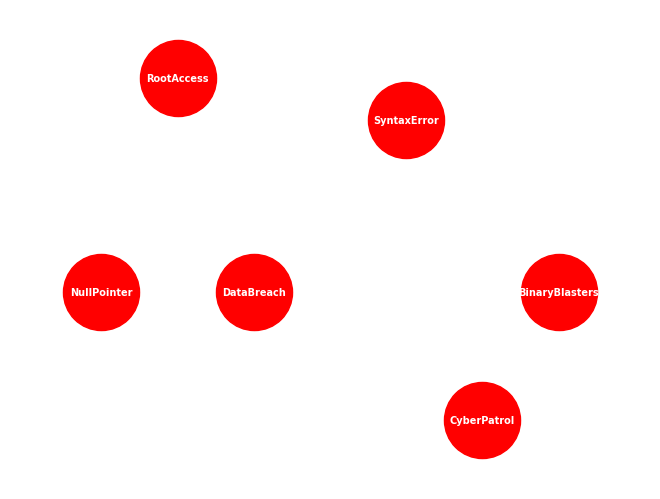

In [13]:
# List nama sindikat gang yang terlibat
nodes = ['NullPointer', 'RootAccess', 'DataBreach', 'SyntaxError', 'BinaryBlasters', 'CyberPatrol']

# Tambahkan node dari daftar sindikat gang yang terlibat
peta_rahasia.add_nodes_from(nodes)

# Tampilkan graf peta_rahasia setelah penambahan node
show_graph(peta_rahasia, pos)


Contoh *output*:

![Contoh output penambahan lokasi](./asset/3_addnodepeta.png)

**c. (5 poin)** Berikut adalah jarak dari setiap rute yang terdapat pada peta rahasia:
- `NullPointer` ke `RootAccess` memiliki rute sepanjang 6 km.
- `NullPointer` ke `DataBreach` memiliki rute sepanjang 3 km.
- `RootAccess` ke `SyntaxError` memiliki rute sepanjang 2 km.
- `DataBreach` ke `SyntaxError` memiliki rute sepanjang 7 km.
- `SyntaxError` ke `BinaryBlasters` memiliki rute sepanjang 4 km.
- `BinaryBlasters` ke `CyberPatrol` memiliki rute sepanjang 5 km.
- `RootAccess` ke `BinaryBlasters` memiliki rute sepanjang 8km.
- `DataBerach` ke `CyberPatrol` memiliki rute sepanjang 9 km.

Tambahkan data rute tersebut ke dalam graf `peta_rahasia`.

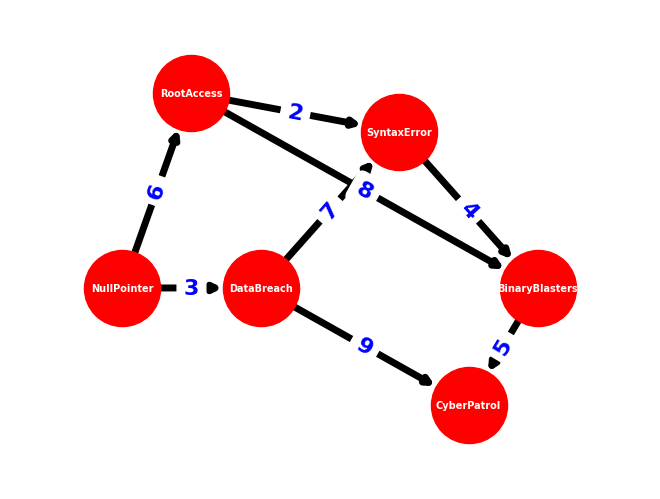

In [14]:
# List jarak suatu markat sindikat ke markas sindikat lainnya
edges = [
    ('NullPointer', 'RootAccess', 6),
    ('NullPointer', 'DataBreach', 3),
    ('RootAccess', 'SyntaxError', 2),
    ('DataBreach', 'SyntaxError', 7),
    ('SyntaxError', 'BinaryBlasters', 4),
    ('BinaryBlasters', 'CyberPatrol', 5),
    ('RootAccess', 'BinaryBlasters', 8),
    ('DataBreach', 'CyberPatrol', 9),
]

# Tambahkan informasi jarak markas para sindikat sebagai edge
peta_rahasia.add_weighted_edges_from(edges)

# Cetak graf
show_graph(peta_rahasia, pos)


Contoh *output*:

![Contoh output penambahan lokasi](./asset/4_addedgepeta.png)

**d. (5 poin)** Buat sebuah program yang memanfaatkan graf `peta_rahasia` untuk mencetak setiap markas dan markas lainnya yang terhubung dengan markas tersebut.

In [15]:
print('Koneksi setiap markas')

# Iterasi untuk setiap node (markas) yang ada di graf `peta_rahasia`
for node in peta_rahasia.nodes():
    # Ambil semua node yang terhubung dengan node saat ini
    children = list(peta_rahasia.successors(node))

    # Jika markas terhubung dengan markas lainnya, tampilkan daftarnya
    if children:
        # Tampilkan nama markas beserta daftar terhubung ke markas lainnya
        print(f'- {node} terhubung dengan: {children}')


Koneksi setiap markas
- NullPointer terhubung dengan: ['RootAccess', 'DataBreach']
- RootAccess terhubung dengan: ['SyntaxError', 'BinaryBlasters']
- DataBreach terhubung dengan: ['SyntaxError', 'CyberPatrol']
- SyntaxError terhubung dengan: ['BinaryBlasters']
- BinaryBlasters terhubung dengan: ['CyberPatrol']


Contoh *output*:

```
Koneksi setiap markas
- NullPointer terhubung dengan: ['RootAccess', 'DataBreach']
- RootAccess terhubung dengan: ['SyntaxError', 'BinaryBlasters']
- DataBreach terhubung dengan: ['SyntaxError', 'CyberPatrol']
- SyntaxError terhubung dengan: ['BinaryBlasters']
- BinaryBlasters terhubung dengan: ['CyberPatrol']
```

**e. (5 poin)** Pada potongan kode dibawah, buat fungsi `heuristable(a, b)`. Karena UCS tidak memperhatikan nilai heuristik, maka cukup kembalikan 0.

In [16]:
def heuristable(a, b):
    return 0 # Kembalikan nilai 0


**f. (5 poin)** Pada potongan kode dibawah, buat kode untuk menemukan rute terpendek antara dua markas dengan mempertimbangkan jarak total antara lokasi awal dan lokasi tujuan yang dimasukkan oleh pengguna.

Dalam proses pencarian rute, gunakan algoritma *Uniform Cost Search (UCS)* yang diimplementasikan menggunakan `astar_path()` pada NetworkX dengan nilai heuristik 0 yang sudah didefinisikan pada fungsi `heuristable()`.

Kemudian tampilkan rute terpendek yang sudah dicari antara titik awal dan titik tujuan yang sudah dimasukkan oleh user serta tampilkan juga besar jarak yang ditempuh dari titik awal ke titik tujuan tersebut.

In [17]:
# Minta input dari pengguna untuk titik awal dan titik tujuan
start_node = input('Masukkan titik awal: ')
end_node = input('Masukkan titik tujuan: ')

# Mencari titik yang dikunjungi dari titik awal ke titik tujuan
path = nx.astar_path(
    peta_rahasia, start_node, end_node, heuristic=heuristable, weight='weight'
)

# Menghitung jarak dari titik awal ke titik tujuan
path_length = nx.astar_path_length(
    peta_rahasia, start_node, end_node, heuristic=heuristable, weight='weight'
)

# Cetak hasil
print(f'Titik yang dikunjungi dari {start_node} ke {end_node}: {path}')
print(f'Besar weight terkecil dari {start_node} ke {end_node}: {path_length} km')


Masukkan titik awal: RootAccess
Masukkan titik tujuan: BinaryBlasters
Titik yang dikunjungi dari RootAccess ke BinaryBlasters: ['RootAccess', 'SyntaxError', 'BinaryBlasters']
Besar weight terkecil dari RootAccess ke BinaryBlasters: 6 km


# Penjelasan

Program ini berfungsi untuk membuat peta koneksi antar markas sindikat dalam bentuk graf berarah, kemudian menampilkan visualisasi peta tersebut beserta jarak antar markas, lalu mencari rute terpendek dari suatu titik awal ke titik tujuan menggunakan algoritma A* (baca: A star).

Pertama, dibuat dictionary `pos` yang berisi koordinat posisi setiap node markas seperti 'NullPointer' di (0,0), 'RootAccess' di (1,5), dan seterusnya.

Kemudian dibuat fungsi pendukung bernama `show_graph` yang bertugas mencetak graf ke layar, fungsi ini punya parameter G (graf), pos (posisi node), dan title (judul).

Di dalam fungsi `show_graph`, jika pos tidak diberikan maka posisi node akan diatur otomatis oleh `nx.spring_layout(G)`.

Setelah itu, fungsi `nx.draw` dipanggil untuk menggambar node-node graf dengan parameter: G sebagai graf, pos sebagai posisi, `with_labels=True` supaya nama node tampil, `node_color='red'` untuk warna merah, `node_size=3000` untuk ukuran node, `font_color="white"` untuk warna tulisan putih, `font_weight="bold"` untuk tulisan tebal, `font_size=7` untuk ukuran font label node, dan `width=5` untuk ketebalan garis edge.

Selanjutnya, fungsi mengambil label edge dari atribut 'weight' dengan `nx.get_edge_attributes(G, 'weight')`, lalu menggambar label edge tersebut menggunakan `nx.draw_networkx_edge_labels` dengan parameter G, pos, `edge_labels=edge_labels` untuk data bobot, `font_color='blue'` untuk warna biru, `font_weight="bold"`, dan `font_size=16`. Kemudian `plt.margins(0.2)` untuk memberi ruang di sekitar plot, `plt.title(title)` untuk menampilkan judul, dan `plt.show()` untuk menampilkan graf.

Setelah fungsi selesai didefinisikan, program membuat graf berarah baru bernama `peta_rahasia` dengan `nx.DiGraph()`. Lalu dibuat list `nodes` berisi nama-nama sindikat: 'NullPointer', 'RootAccess', 'DataBreach', 'SyntaxError', 'BinaryBlasters', 'CyberPatrol'.

Node-node tersebut ditambahkan ke graf menggunakan `peta_rahasia.add_nodes_from(nodes)`. Kemudian graf pertama yang masih tanpa edge ditampilkan lewat `show_graph(peta_rahasia, pos)`.

Selanjutnya dibuat list `edges` yang berisi tiga nilai tiap elemen: node asal, node tujuan, dan jarak antar markas (dalam km). Contoh edge: ('NullPointer', 'RootAccess', 6) berarti jarak dari NullPointer ke RootAccess adalah 6 km. Semua edge ini ditambahkan ke graf sekaligus dengan fungsi `peta_rahasia.add_weighted_edges_from(edges)`.

Setelah edge ditambahkan, graf yang sudah lengkap ditampilkan lagi dengan `show_graph(peta_rahasia, pos)`. Program lalu mencetak tulisan 'Koneksi setiap markas' dan melakukan iterasi untuk setiap node yang ada di graf `peta_rahasia` menggunakan perulangan `for node in peta_rahasia.nodes():`.

Di dalam perulangan, diambil semua node yang terhubung dari node saat ini (arah keluar) dengan `peta_rahasia.successors(node)` dan diubah menjadi list. Jika ternyata ada isinya (markas tersebut terhubung ke markas lain), maka program mencetak `- {node} terhubung dengan: {children}`.

Setelah itu, dibuat fungsi `heuristable(a, b)` yang selalu mengembalikan nilai 0, fungsi ini berperan sebagai heuristik untuk algoritma A* (baca: A star) tapi karena di sini dikembalikan 0, maka algoritma akan berperilaku seperti Dijkstra.

Program meminta input dari pengguna untuk titik awal dan titik tujuan dengan `input('Masukkan titik awal: ')` dan `input('Masukkan titik tujuan: ')`. Nilai input tersebut disimpan di variabel `start_node` dan `end_node`.

Kemudian program mencari jalur node yang dikunjungi dari start ke end menggunakan `nx.astar_path` dengan parameter graf, start_node, end_node, `heuristic=heuristable`, dan `weight='weight'`. Hasilnya disimpan di variabel `path`. Selanjutnya menghitung total jarak (bobot terkecil) dari start ke end menggunakan `nx.astar_path_length` dengan parameter yang sama, hasilnya di `path_length`.

Terakhir, program mencetak dua baris: pertama `Titik yang dikunjungi dari {start_node} ke {end_node}: {path}` yang menampilkan urutan markas yang dilewati, dan kedua `Besar weight terkecil dari {start_node} ke {end_node}: {path_length} km` yang menampilkan total jarak dalam satuan km.

Contoh *output*:

|input|output|
|-----|------|
|Masukkan titik awal: `RootAccess`<br>Masukkan titik tujuan: `BinaryBlasters`|Titik yang dikunjungi dari RootAccess ke BinaryBlasters: ['RootAccess', 'SyntaxError', 'BinaryBlasters']<br>Besar weight terkecil dari RootAccess ke BinaryBlasters: 6 km|
|Masukkan titik awal: `NullPointer`<br>Masukkan titik tujuan: `CyberPatrol`|Titik yang dikunjungi dari NullPointer ke CyberPatrol: ['NullPointer', 'DataBreach', 'CyberPatrol']<br>Besar weight terkecil dari NullPointer ke CyberPatrol: 12 km|

### 3. Soal Mandiri (40)

Seorang insinyur jaringan sedang memetakan infrastruktur jaringan komputer di sebuah perusahaan besar. Infrastruktur ini direpresentasikan sebagai sebuah *tree*, di mana setiap node mewakili perangkat jaringan seperti `Server (S)`, `Router (R)`, `Switch (S)`, dan `Computer (C)`. Hubungan antara node menunjukkan koneksi fisik antar perangkat tersebut.

Setiap koneksi memiliki bobot yang merepresentasikan *latency* dalam milidetik (ms) antara perangkat-perangkat tersebut. Bantu insinyur untuk menghitung latensi dari suatu perangkat ke perangkat lain dengan menggunakan algoritma *Uniform Cost Search* untuk menemukan rute dengan total latensi terendah pada jaringan komputer perusahaan yang direpresentasikan sebagai *tree*.

Kemudian, buat program yang dapat menghitung *latency* dari perangkat sumber ke perangkat tujuan. Minta nilai perangkat sumber dan perangkat tujuan dari *input user*.

Berikut adalah nama perangkat yang terdapat dalam jaringan. Buat kode-perangkat sebagai nama node.
|Nama|Kode-Perangkat|
|----|--------------|
|Server Utama|S|
|Router-A|R-A|
|Router-B|R-B|
|Switch-A1|Sw-A1|
|Switch-A2|Sw-A2|
|Switch-B|Sw-B1|
|Computer-A1|C-A1|
|Computer-A2|C-A2|
|Computer-B1|C-B1|
|Computer-B2|C-B2|

Berikut adalah latency koneksi antara device dalam satuan milidetik (ms)
|Sumber|Tujuan|*Latency*|
|------|------|---------|
|S|R-A|5ms|
|S|R-B|3ms|
|R-A|Sw-A1|2ms|
|R-A|Sw-A2|4ms|
|R-B|Sw-B|6ms|
|Sw-A1|C-A1|3ms|
|Sw-A2|C-A2|7ms|
|Sw-B1|C-B1|5ms|
|Sw-B1|C-B2|2ms|

Instruksi:
- Buatlah sebuah *tree* yang merepresentasikan jaringan komputer di perusahan tersebut menggunakan NetworkX dengan jenis graf tidak berarah.
- Tampilkan *tree* yang sudah dibuat dengan `show_graph()`.
- Minta input pengguna untuk `perangkat sumber` dan `perangkat tujuan` yang akan ditelusuri.
- Implementasikan algoritma UCS dengan menggunakan `astar_path()` dengan nilai heuristik 0.
- Tampilkan rute yang dilalui dari perangkat sumber ke perangkat tujuan beserta *latency*nya

### Fungsi pendukung untuk mencetak graf

#### **!! Tidak usah dimodifikasi !!**

In [18]:
# Posisi setiap node dalam tree
pos = {
    'S': (0, 4),
    'R-A': (-2, 2),
    'R-B': (2, 2),
    'Sw-A1': (-3, 0),
    'Sw-A2': (-1, 0),
    'Sw-B1': (2, 0),
    'C-A1': (-3, -2),
    'C-A2': (-1, -2),
    'C-B1': (1, -2),
    'C-B2': (3, -2)
}


In [19]:
# Fungsi pendukung untuk mencetak graf
def show_graph(G, pos=None, title='') :
  # Membuat pos jika pos tidak diberikan
  if pos is None:
      pos = nx.spring_layout(G)

  # Fungsi untuk menggambar node
  nx.draw(
      G,                  # Graf NetworkX
      pos,                # Posisi node
      with_labels=True,   # Menampilkan nama node
      node_color='red',   # Warna node
      node_size=2000,     # Ukuran node
      font_color="white", # Warna font label node
      font_weight="bold", # Ketebalan font label node
      width=5             # Ketebalan garis edge
  )

  # Mengambil label edge jika ada weight
  edge_labels = nx.get_edge_attributes(G, 'weight')
  # Fungsi untuk menggambar node
  nx.draw_networkx_edge_labels(
      G,
      pos,
      edge_labels=edge_labels, # Data weight
      font_color='blue',       # Warna font label edge
      font_weight="bold",      # Berat font label edge
      font_size=16,            # Ukuran font label edge
  )

  plt.margins(0.2)  # Memberikan margin pada plot
  plt.title(title)  # Menampilkan judul graf jika diberikan
  plt.show()

**Kerjakan soal mandiri pada blok kode dibawah**

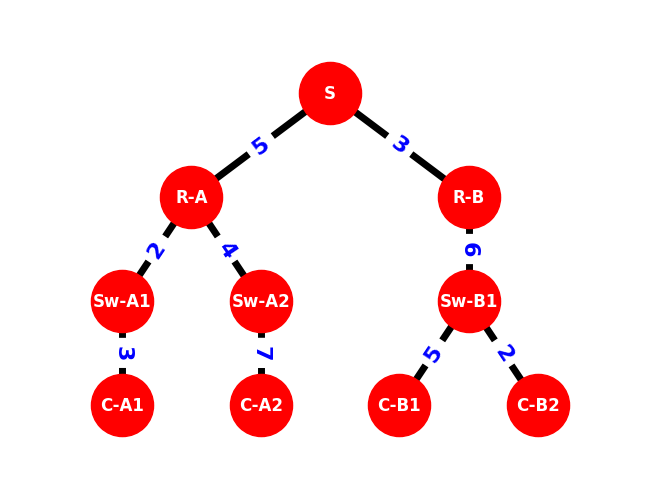

Masukkan perangkat sumber: S
Masukkan perangkat tujuan: C-B1
Perangkat yang dikunjungi dari S ke C-B1: ['S', 'R-B', 'Sw-B1', 'C-B1']
Besar latency dari S ke C-B1: 14ms


In [20]:
### GRAF SECTION
# buat graf
jaringan = nx.Graph()

# buat nodes dan tambahkan ke graf
nodes = ['S', 'R-A', 'R-B', 'Sw-A1', 'Sw-A2', 'Sw-B1', 'C-A1', 'C-A2', 'C-B1', 'C-B2']

jaringan.add_nodes_from(nodes)

# hubungkan dengan edge dan tambahkan ke graf sesuai informasi
edges = [
    ('S', 'R-A', 5),
    ('S', 'R-B', 3),
    ('R-A', 'Sw-A1', 2),
    ('R-A', 'Sw-A2', 4),
    ('R-B', 'Sw-B1', 6),
    ('Sw-A1', 'C-A1', 3),
    ('Sw-A2', 'C-A2', 7),
    ('Sw-B1', 'C-B1', 5),
    ('Sw-B1', 'C-B2', 2),
]

jaringan.add_weighted_edges_from(edges)

# tampilkan graf yang telah dibuat
show_graph(jaringan, pos)

### IMPLEMENTASI UCS
# buat fungsi heuristable
def heuristable(a, b):
    return 0

start_node = 'S'
end_node = 'C-B1'

print(f'Masukkan perangkat sumber: {start_node}')
print(f'Masukkan perangkat tujuan: {end_node}')

# buat path dari contoh yang telah diberikan
path = nx.astar_path(
    jaringan, start_node, end_node, heuristic=heuristable, weight='weight'
)

path_length = nx.astar_path_length(
    jaringan, start_node, end_node, heuristic=heuristable, weight='weight'
)

# print informasi dari path yang telah dibuat
print(f'Perangkat yang dikunjungi dari {start_node} ke {end_node}: {path}')
print(f'Besar latency dari {start_node} ke {end_node}: {path_length}ms')

# Penjelasan

Program ini berfungsi untuk membuat sebuah jaringan atau graf yang merepresentasikan jalur dari perangkat sumber ke perangkat tujuan, kemudian menghitung jalur terpendek berdasarkan nilai latency atau weight menggunakan algoritma UCS yang dijalankan lewat fungsi astar_path dengan heuristik nol.

Pertama, ada dictionary dengan nama `pos` yang berisi posisi koordinat setiap node di dalam tree, node-node tersebut antara lain 'S', 'R-A', 'R-B', 'Sw-A1', 'Sw-A2', 'Sw-B1', 'C-A1', 'C-A2', 'C-B1', dan 'C-B2'. Tiap node punya pasangan koordinat x dan y, misalnya 'S' di (0,4) dan seterusnya, gunanya untuk mengatur letak node saat digambar nanti biar rapi dan tidak acak.

Kemudian dibuat fungsi pendukung bernama `show_graph` yang bertugas untuk mencetak atau menampilkan graf ke layar. Fungsi ini punya tiga parameter, yaitu `G` sebagai graf dari NetworkX, `pos` untuk posisi node kalau ada, dan `title` untuk judul gambar.

Di dalam fungsi, pertama dicek kalau `pos` tidak diberikan maka akan dibuat otomatis pakai `nx.spring_layout`. Setelah itu, fungsi `nx.draw` dipanggil untuk menggambar node-node dengan warna merah, ukuran node 2000, font label putih dan tebal, serta ketebalan garis edge 5.

Lalu fungsi `nx.draw_networkx_edge_labels` mengambil atribut 'weight' dari setiap edge untuk dijadikan label, label edge ditampilkan dengan warna biru, font tebal, dan ukuran 16. Terakhir, `plt.margins(0.2)` kasih ruang di sekeliling plot, `plt.title` menampilkan judul, dan `plt.show()` untuk memunculkan gambar.

Masuk ke bagian GRAF SECTION, pertama dibuat graf kosong dengan tipe `nx.Graph()`. Kemudian dibuat list `nodes` yang isinya semua nama node yang sama seperti di dictionary `pos`, lalu ditambahkan ke graf pakai `jaringan.add_nodes_from(nodes)`.

Selanjutnya dibuat list `edges` yang berisi koneksi antar node beserta weight atau latency masing-masing, misalnya dari 'S' ke 'R-A' dengan weight 5, dari 'S' ke 'R-B' dengan weight 3, dan seterusnya sampai edge terakhir dari 'Sw-B1' ke 'C-B2' dengan weight 2.

Semua edge ini langsung ditambahkan ke graf menggunakan `jaringan.add_weighted_edges_from(edges)`. Setelah graf selesai dibuat, fungsi `show_graph` dipanggil dengan mengirimkan graf `jaringan` dan posisi `pos` agar tampilannya teratur.

Bagian terakhir adalah IMPLEMENTASI UCS. Pertama dibuat fungsi `heuristable` yang menerima dua parameter `a` dan `b` tapi selalu mengembalikan nilai 0, ini karena jalur yang dicari tidak menggunakan heuristik (cuma mengandalkan weight saja, jadi mirip Dijkstra).

Kemudian ditentukan `start_node` atau perangkat sumber bernama 'S', dan `end_node` atau perangkat tujuan bernama 'C-B1'. Lalu dicetak ke layar tulisan 'Masukkan perangkat sumber: S' dan 'Masukkan perangkat tujuan: C-B1' biar user tahu.

Selanjutnya jalur terpendek dicari dengan `nx.astar_path` yang parameternya adalah graf, node awal, node akhir, fungsi heuristik yang sudah dibuat, dan weight sebagai acuan biaya. Hasilnya disimpan di variabel `path`. Panjang jalur atau total latency dihitung dengan `nx.astar_path_length` dengan parameter yang sama, hasilnya di `path_length`.

Terakhir, dicetak informasi 'Perangkat yang dikunjungi dari S ke C-B1: diikuti isi list path' dan 'Besar latency dari S ke C-B1: diikuti nilai path_length lalu ditambah tulisan ms' untuk menunjukkan satuan milidetik. Maka dari itu, program ini bisa menentukan rute terbaik dari node S ke node C-B1 berdasarkan nilai weight yang sudah ditentukan di setiap edge.

Contoh *output*:

![Contoh Graf Network](./asset/5_grafnetwork.png)

|Input|Output|
|-----|------|
|Masukkan titik awal: `S`<br>Masukkan titik tujuan: `C-B1`|Perangkat yang dikunjungi dari S ke C-B1: ['S', 'R-B', 'Sw-B1', 'C-B1']<br>Besar latency dari S ke C-B1: 14ms|